In [1]:
import uproot
import matplotlib.pyplot as plt
import pandas as pd
import tqdm
import numpy as np
import os
import glob
import awkward as ak
import boost_histogram as bh
import mplhep
from matplotlib.colors import LogNorm
import math
# !pip install pyarrow
# !pip install "pyarrow<21" --break-system-packages

In [2]:
files_fasernu = ["build/200093.bck.root",
         "build/200094.bck.root",
         "build/200100.bck.root",]


hists_fasernu = {}
for file in files_fasernu:
    with uproot.open(file) as f:
        hists_dir = f["histograms"]
        for hist_name in hists_dir.keys():
            hist = hists_dir[hist_name].to_boost()
            if hist_name not in hists_fasernu   :
                hists_fasernu[hist_name] = hist
            else:
                hists_fasernu[hist_name] += hist

In [3]:
files_calonuu = ["build/200139.bck.root",
         "build/200140.bck.root",
         "build/200146.bck.root",]

hists_calonuu = {}
for file in files_calonuu:
    with uproot.open(file) as f:
        hists_dir = f["histograms"]
        for hist_name in hists_dir.keys():
            hist = hists_dir[hist_name].to_boost()
            if hist_name not in hists_calonuu   :
                hists_calonuu[hist_name] = hist
            else:
                hists_calonuu[hist_name] += hist

In [4]:
# for hist_name, hist_fasernu in hists_fasernu.items():
#     fig, ax = plt.subplots(figsize=(10, 6), nrows=2, sharex=True    )
#     hist_calonuu = hists_calonuu.get(hist_name)

#     hist_calonuu *= 0.68 / 1.1


#     try:
#         mplhep.histplot(hist_fasernu, ax=ax[0], density=True, histtype="step", label=hist_name, flow="show")
#         mplhep.histplot(hist_calonuu, ax=ax[0], density=True, histtype="step", label=hist_name, flow="show")
#     except Exception as e:
#         continue

#     if "truth_dec_x_nu" in hist_name:
#         ax[0].axvline(-115, color='r', linestyle='--')
#         ax[0].axvline(135, color='r', linestyle='--')
#     elif "truth_dec_y_nu" in hist_name:
#         ax[0].axvline(-171, color='r', linestyle='--')
#         ax[0].axvline(129, color='r', linestyle='--')
#     elif "truth_dec_z_nu" in hist_name:
#         ax[0].axvline(-3000, color='r', linestyle='--')
#         ax[0].axvline(-1950, color='r', linestyle='--')
#     elif "truth_dec_r" in hist_name:
#         ax[0].axvline(100, color='r', linestyle='--')
    
#     ratio = hist_calonuu / hist_fasernu

#     # # Set Nans in ratio to 0
#     # ratio_ = ratio.to_numpy()[0]
#     # ratio_ = np.nan_to_num(ratio_, nan=0.0, posinf=0.0, neginf=0.0)

#     for i in range(len(ratio.axes[0].edges) - 1):
#         if math.isnan(ratio[i]) or math.isinf(ratio[i]):
#             ratio[i] = 0.
#         # else:
#         #     print(f"ratio[{i}] = {ratio[i]}, {type(ratio[i])}")

#     mplhep.histplot(ratio, ax=ax[1], density=True, histtype="step", label="Ratio", flow="show")
#     ax[1].set_ylabel("Ratio")
#     # print(ratio)
#     # ax[1].set_ylim(0, np.amax(ratio.to_numpy()[0]) * 1.2)
    
#     ax[0].set_title(hist_name)

/tmp/ipykernel_2994580/463406625.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(10, 6), nrows=2, sharex=True    )
/home/ppd/bewilson/miniconda3/envs/faser/lib/python3.12/site-packages/mplhep/utils.py:703: RuntimeWarning: invalid value encountered in multiply
  self._values *= scale
/home/ppd/bewilson/miniconda3/envs/faser/lib/python3.12/site-packages/mplhep/utils.py:703: RuntimeWarning: invalid value encountered in multiply
  self._values *= scale


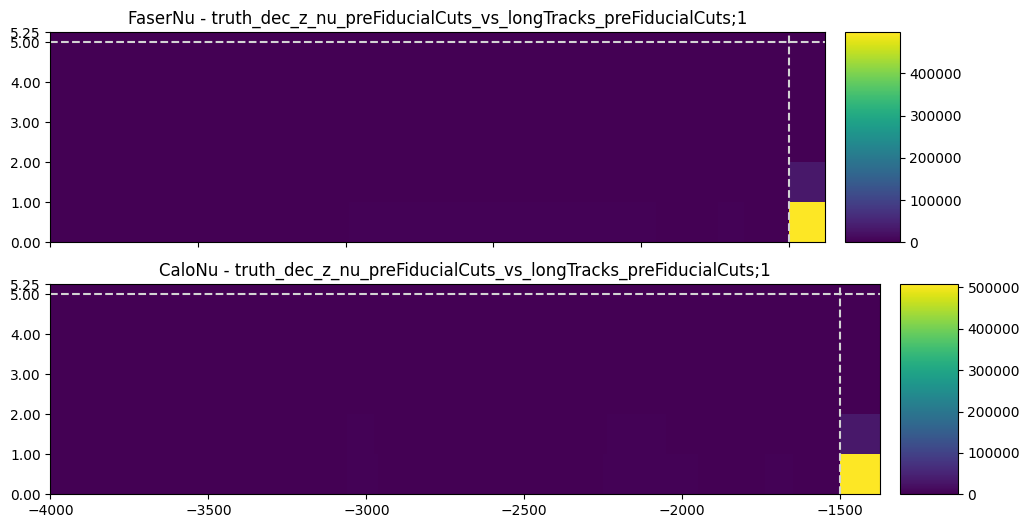

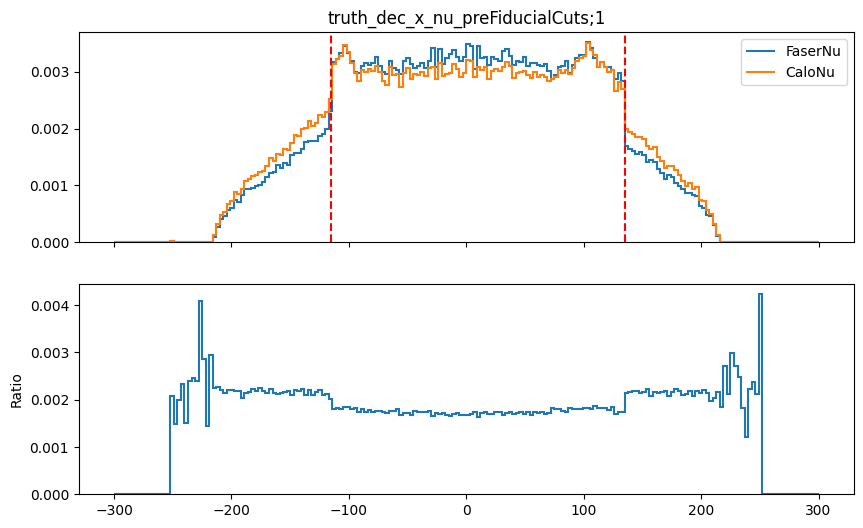

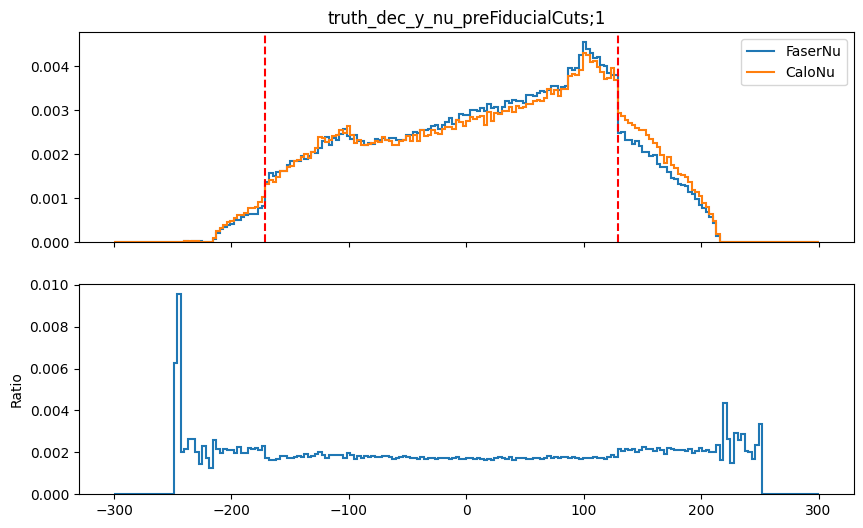

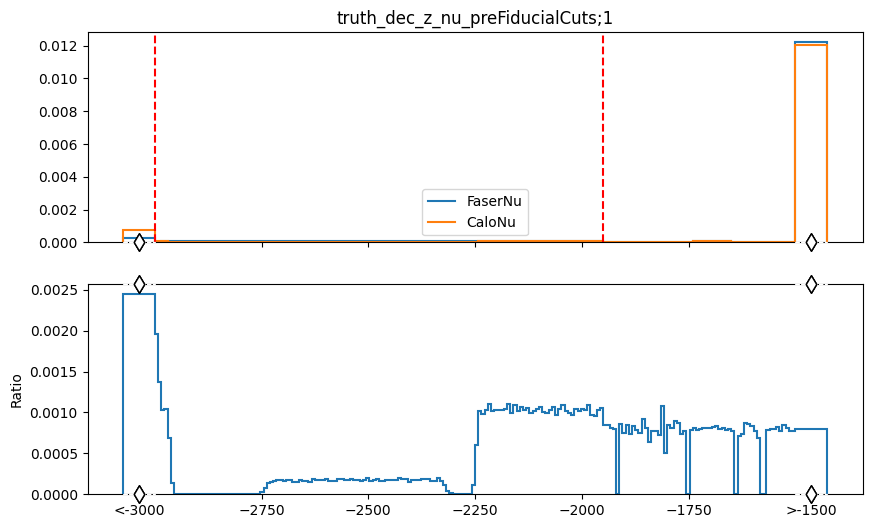

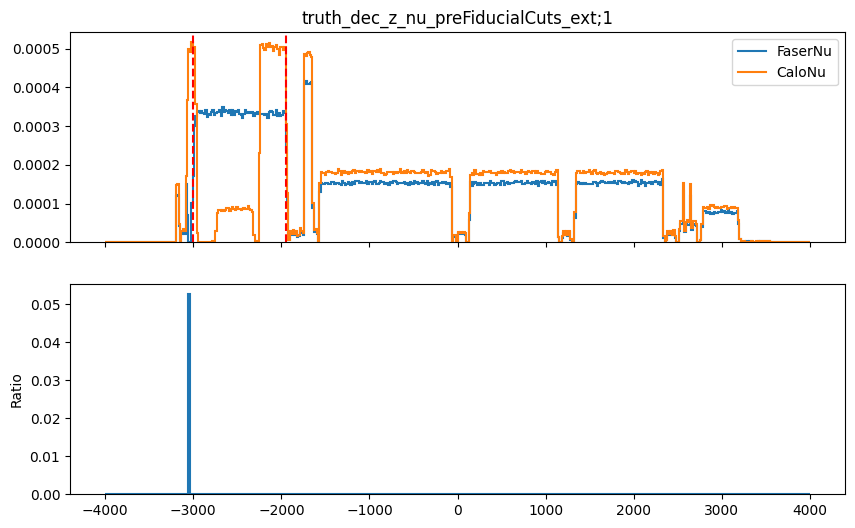

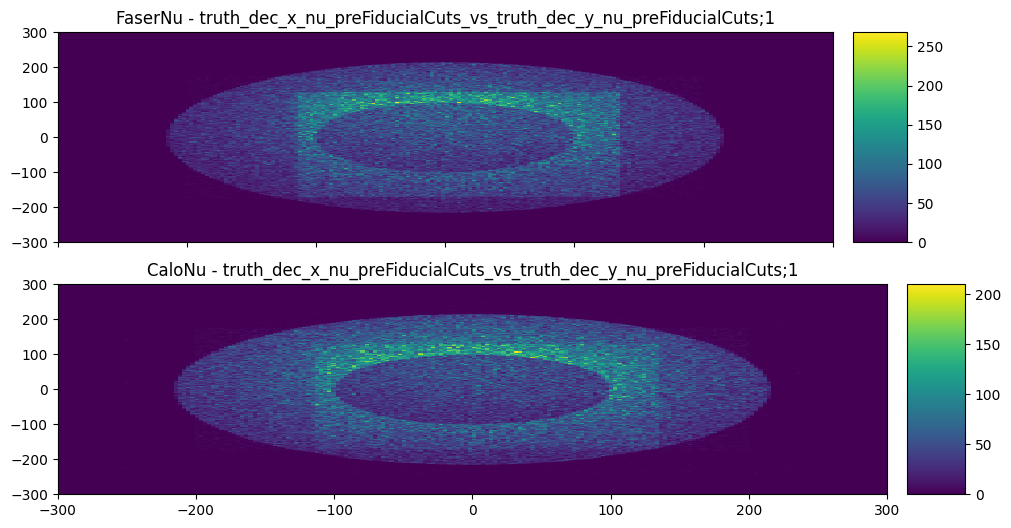

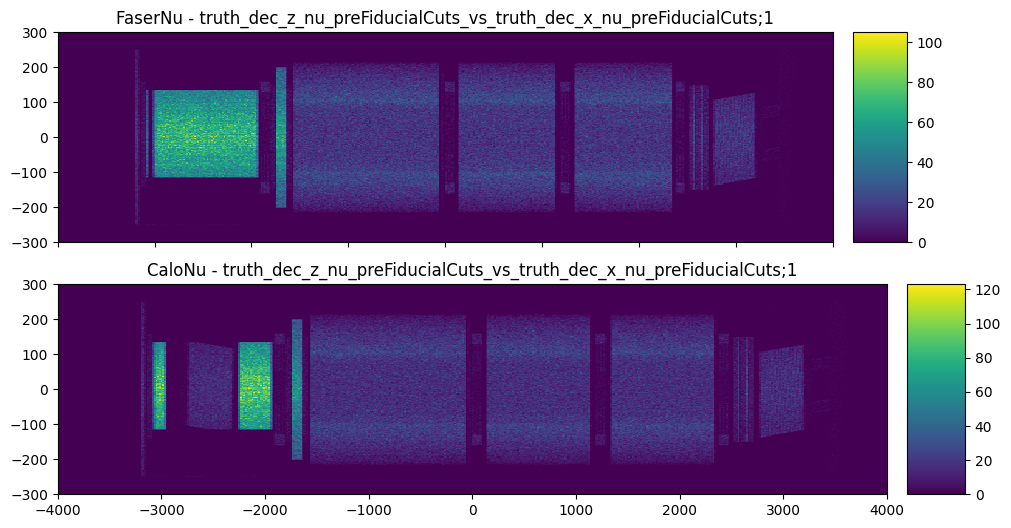

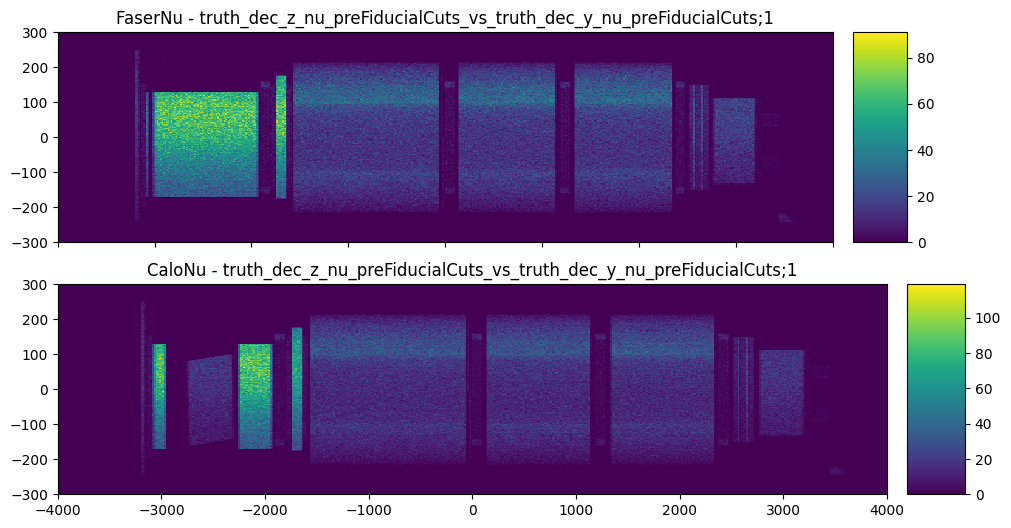

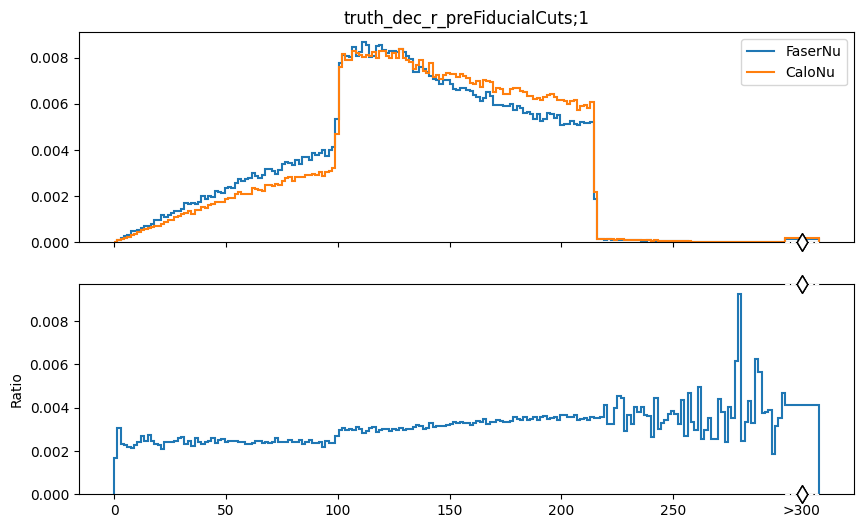

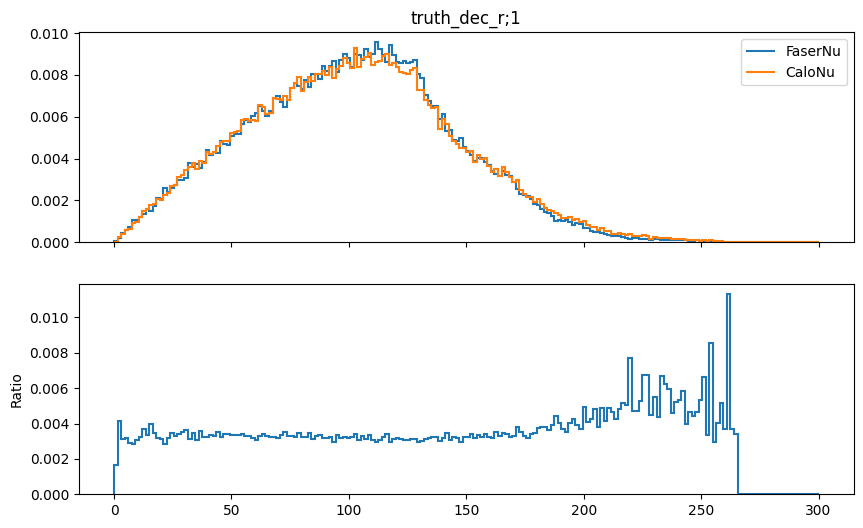

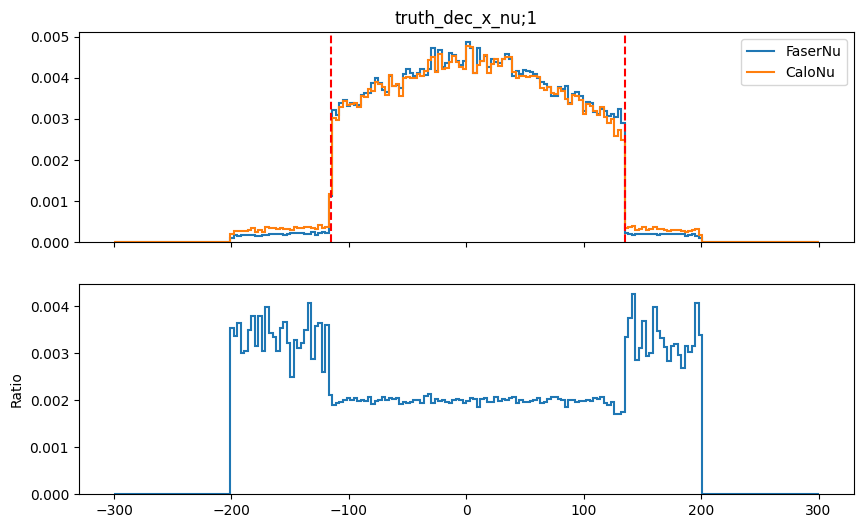

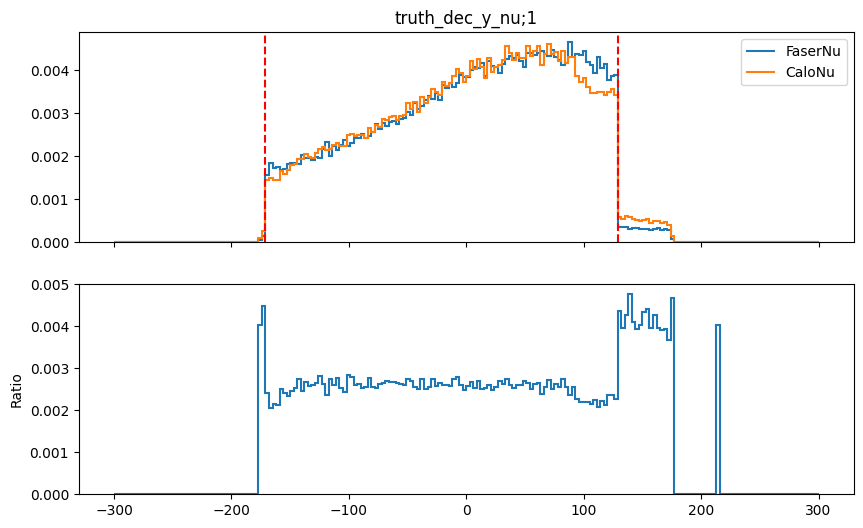

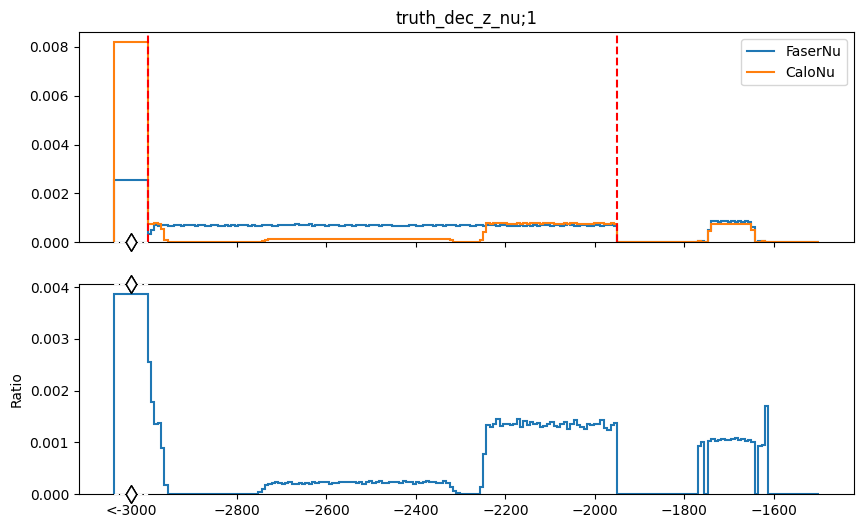

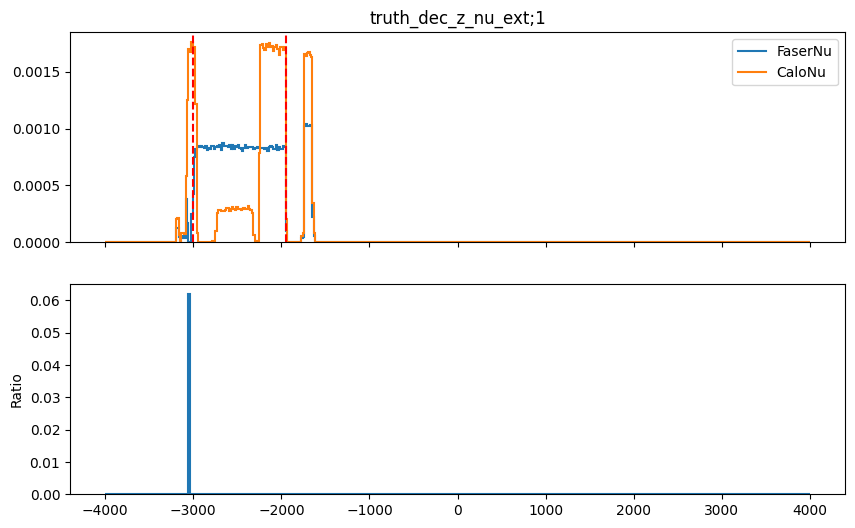

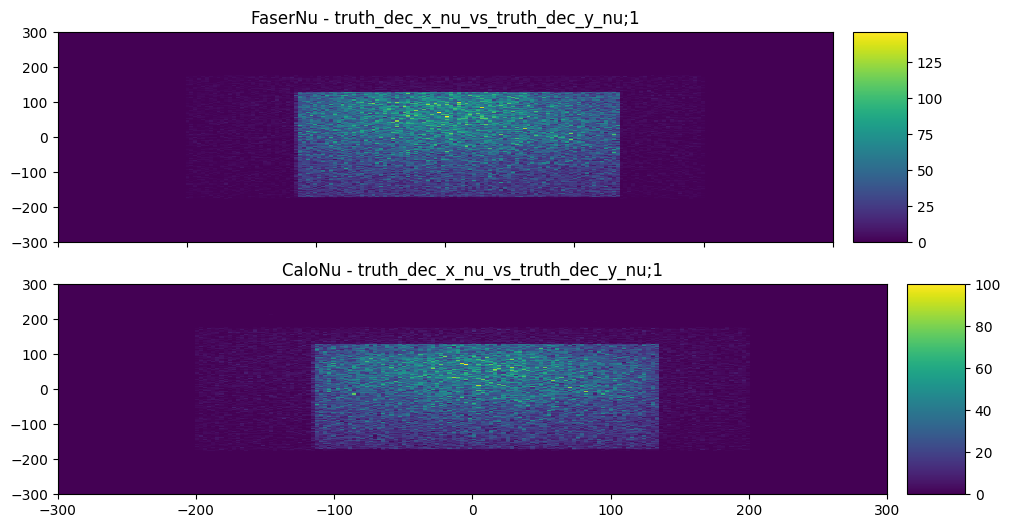

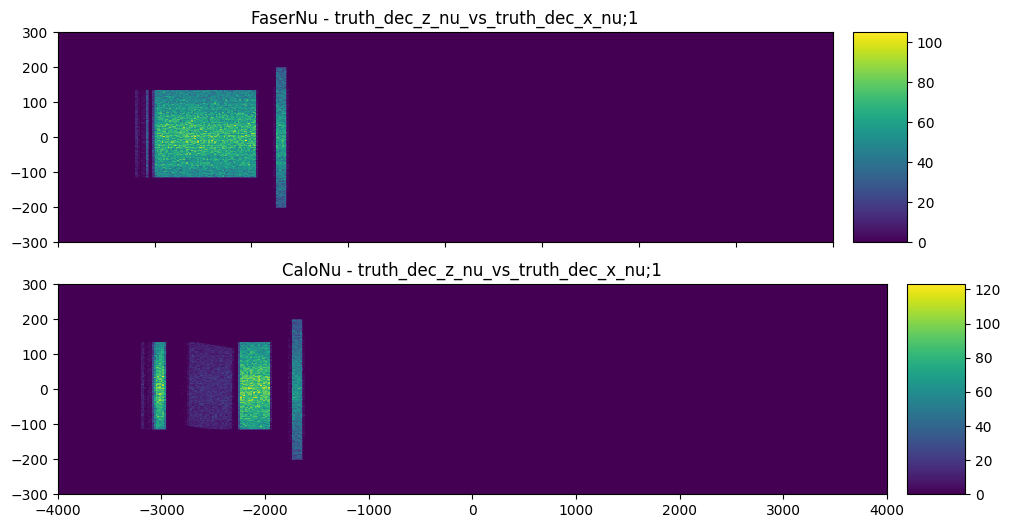

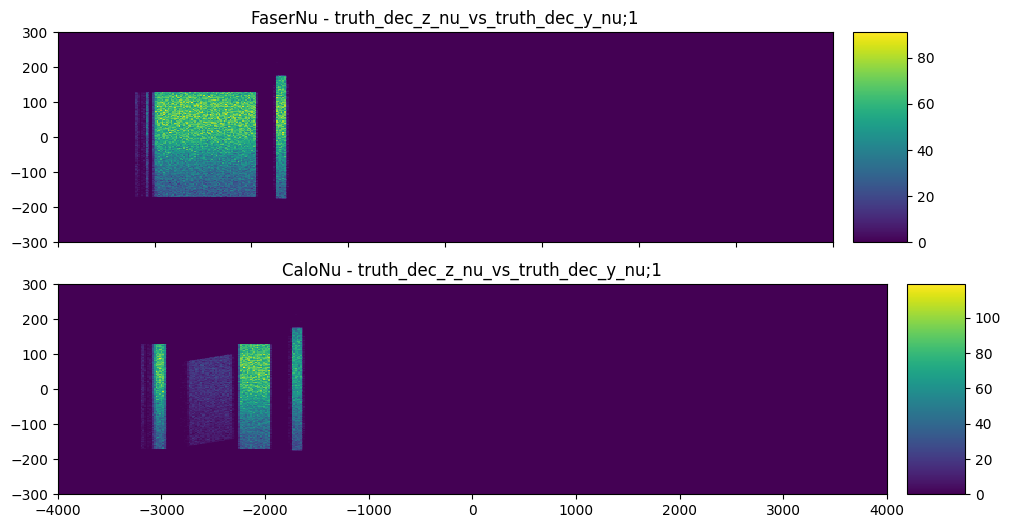

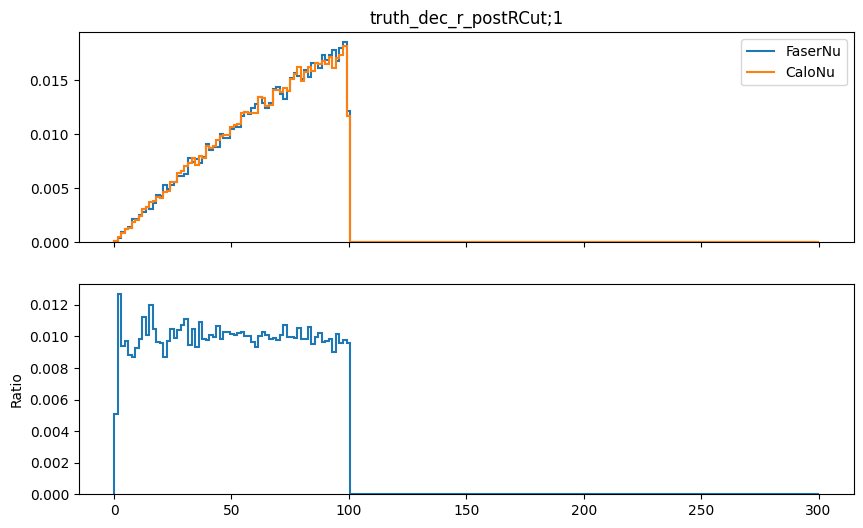

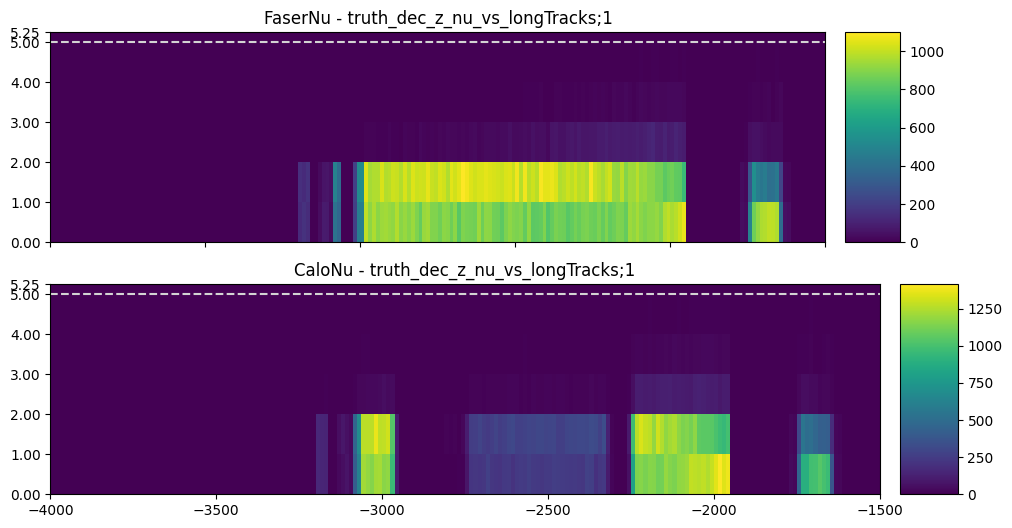

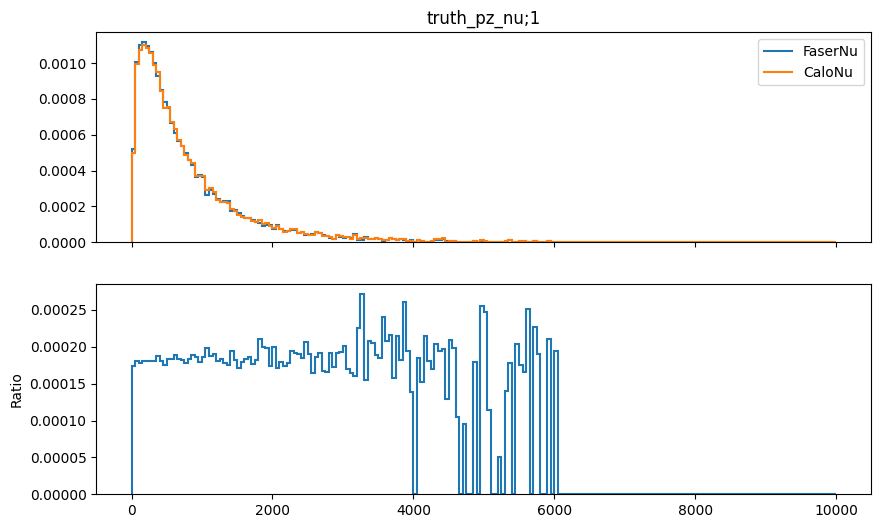

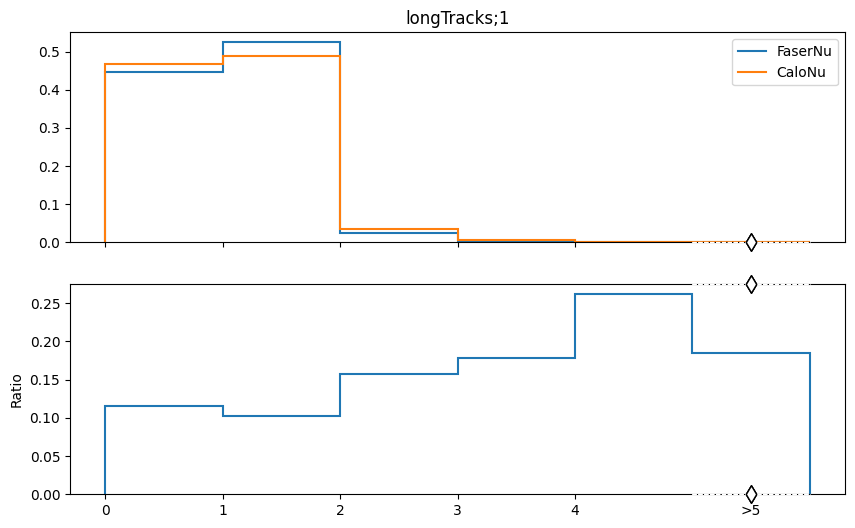

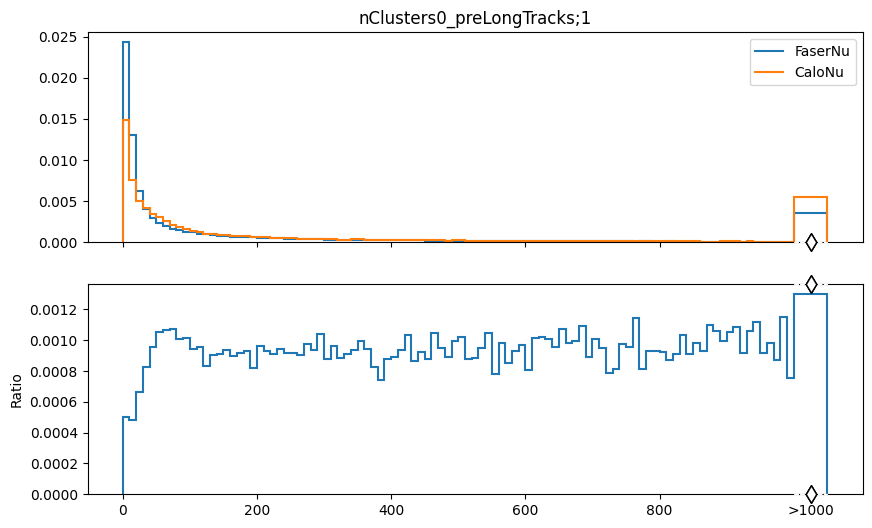

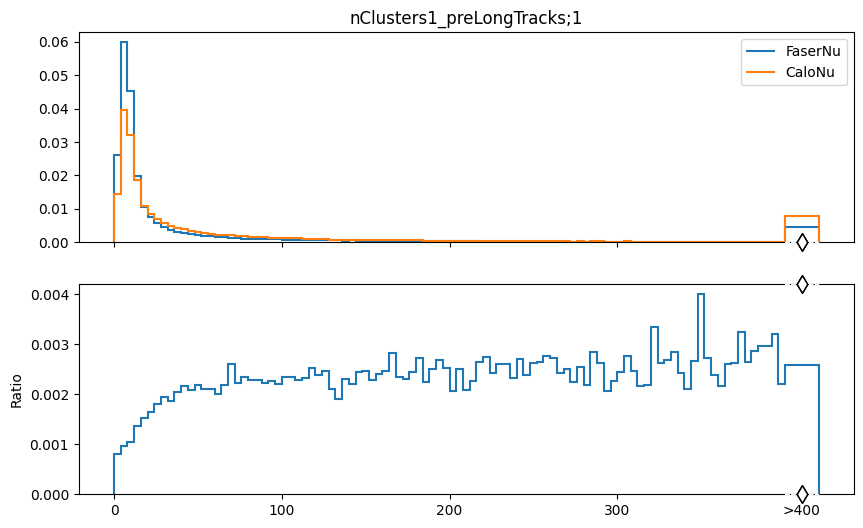

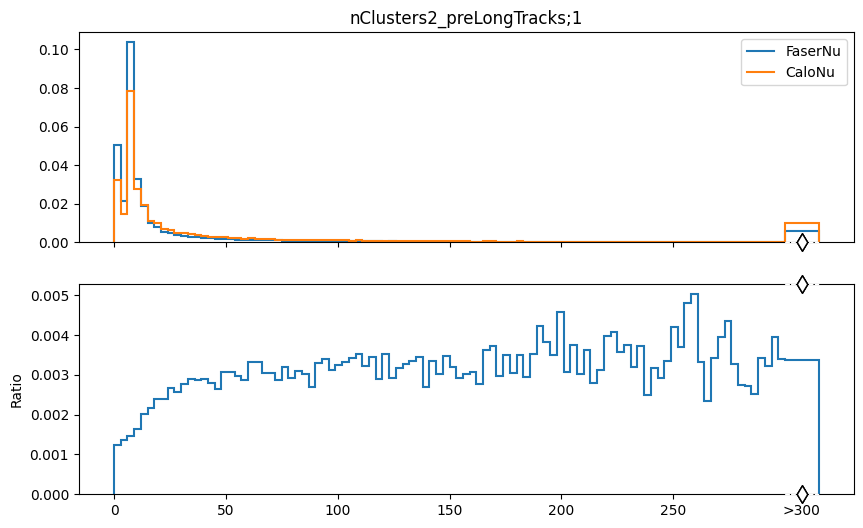

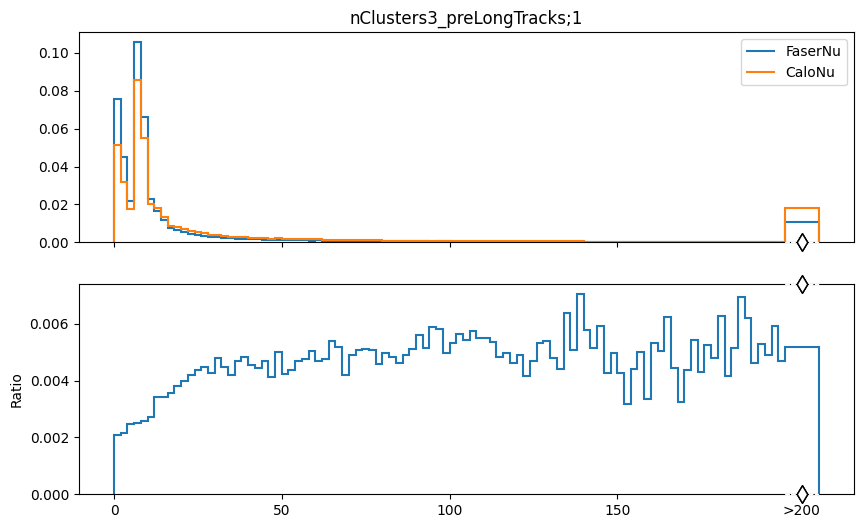

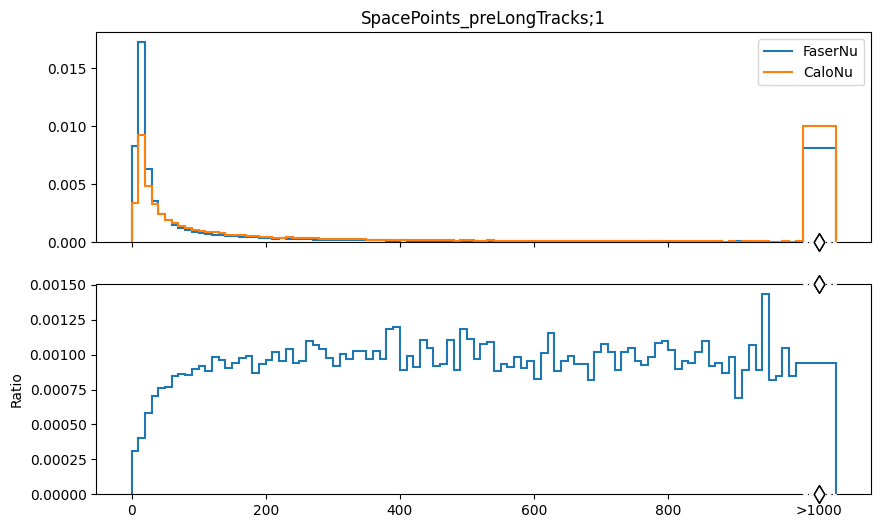

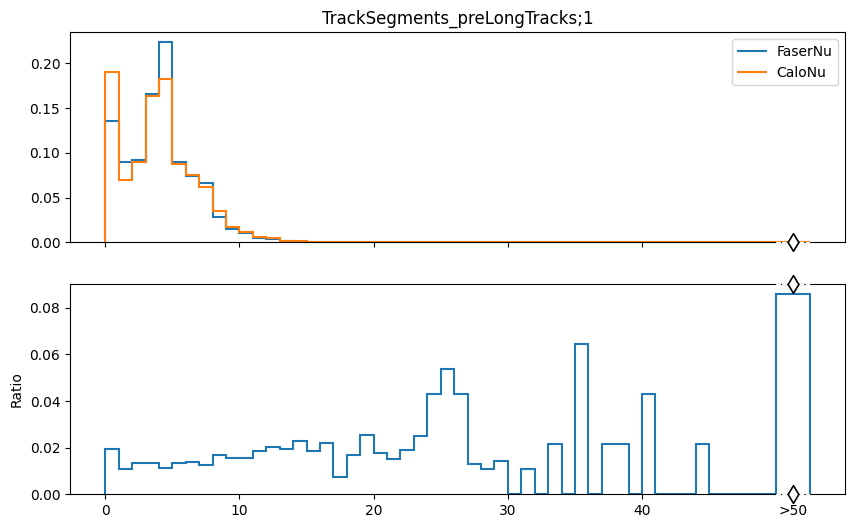

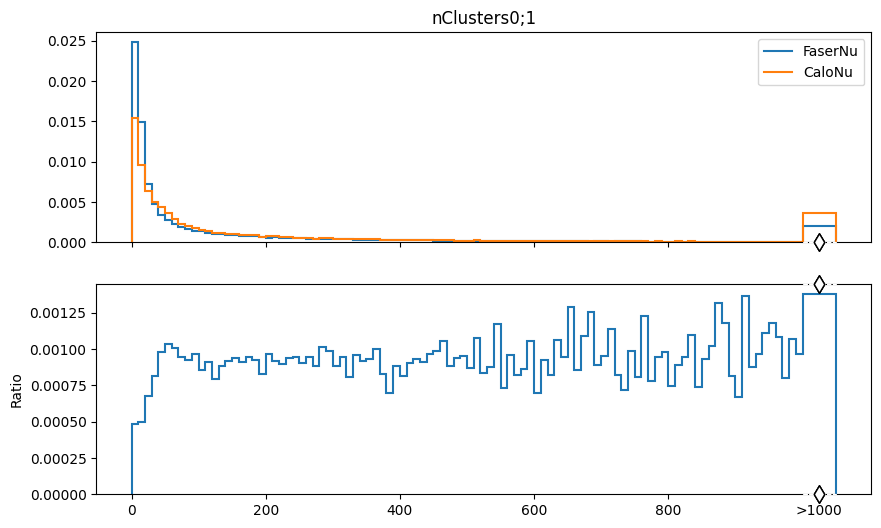

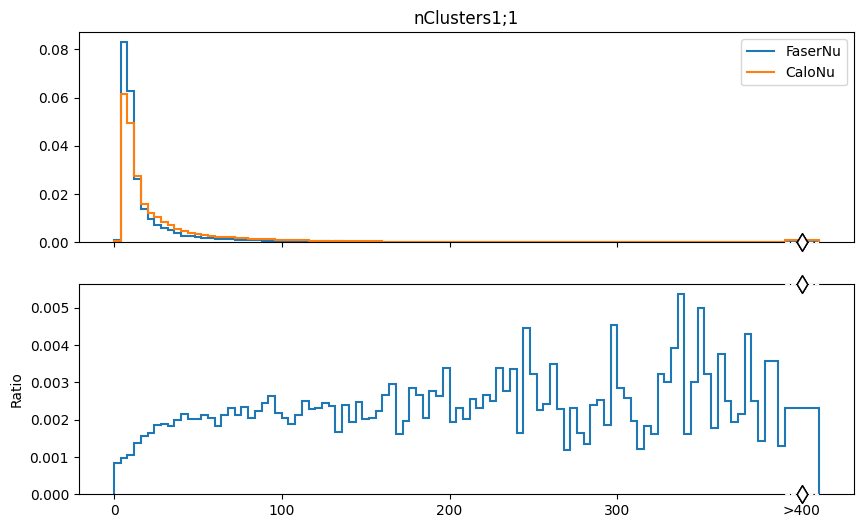

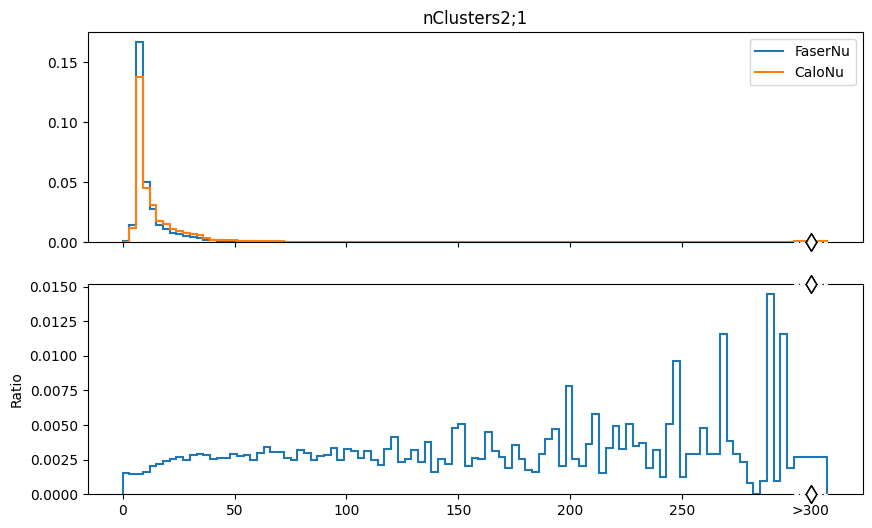

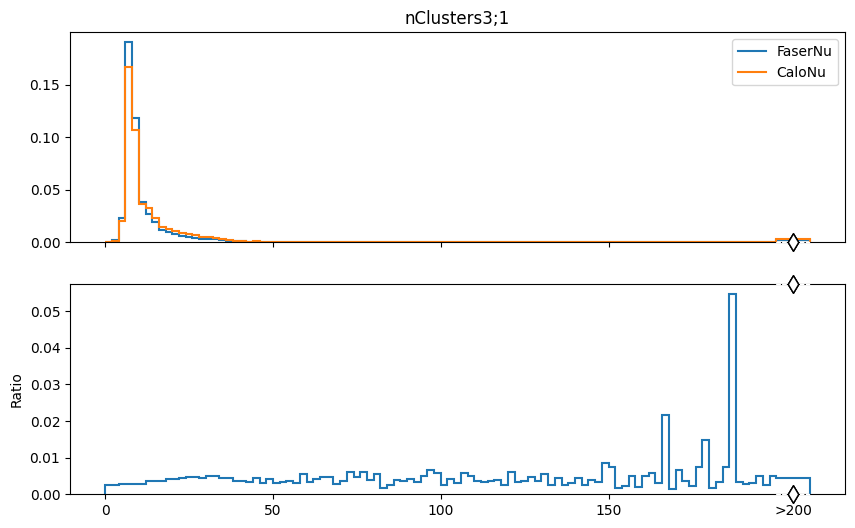

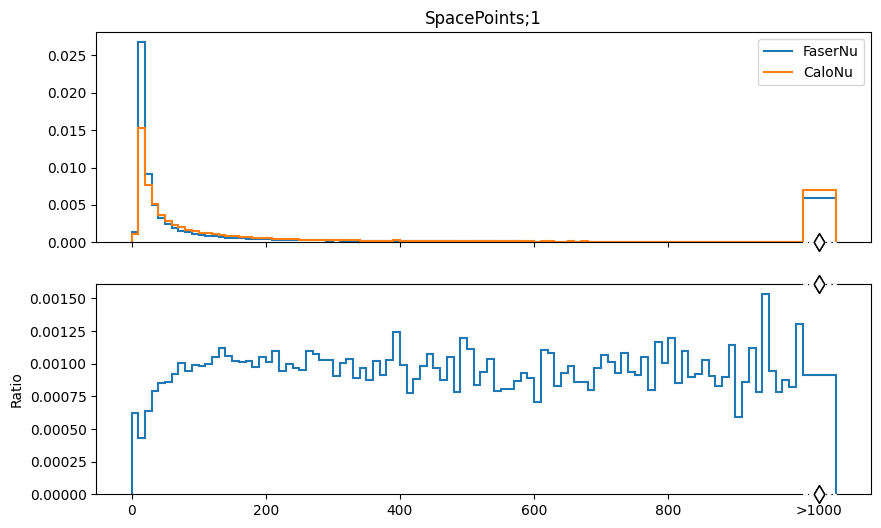

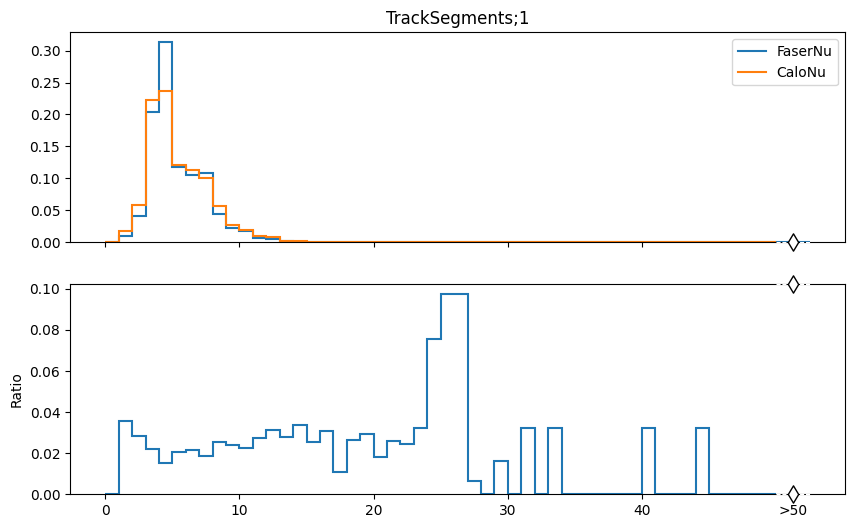

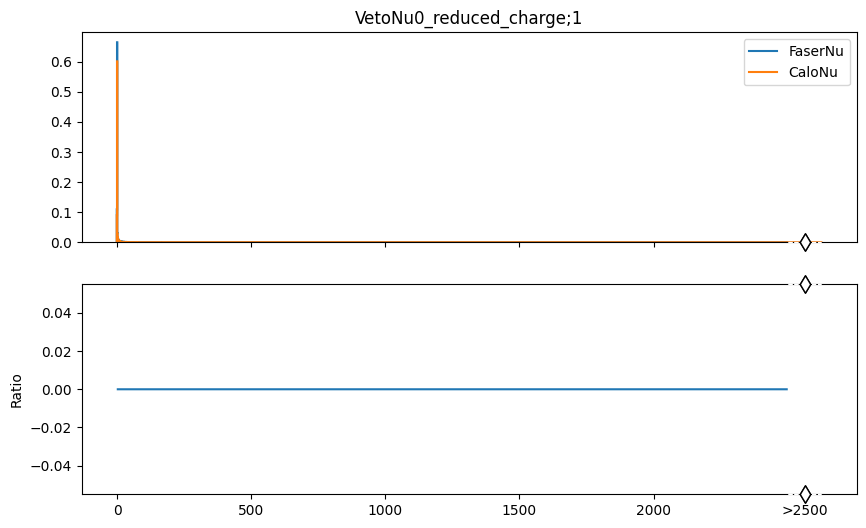

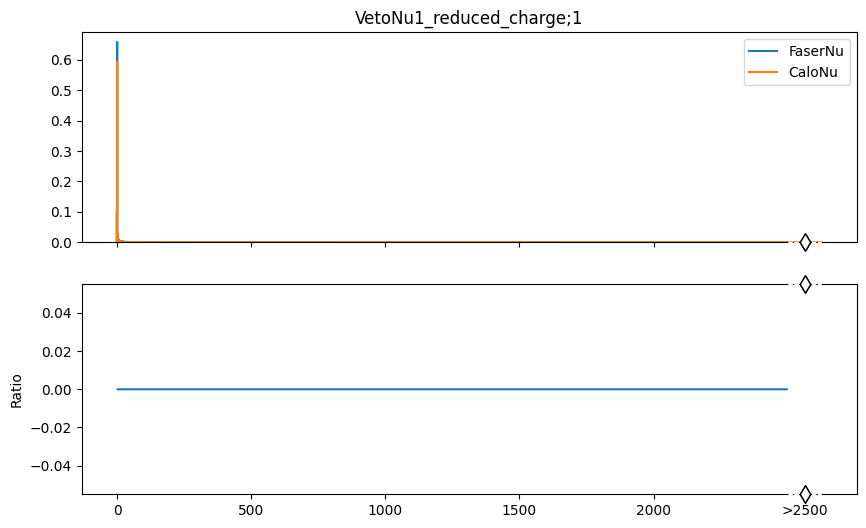

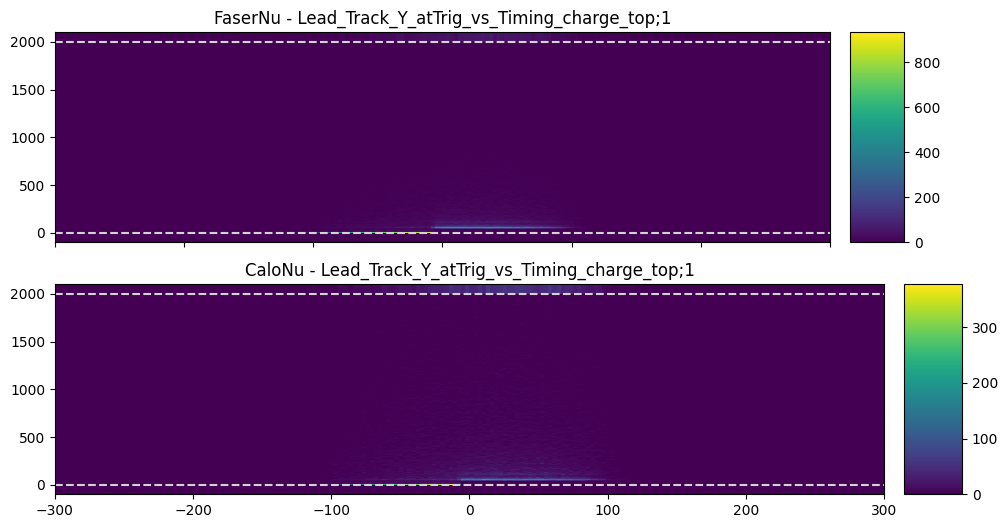

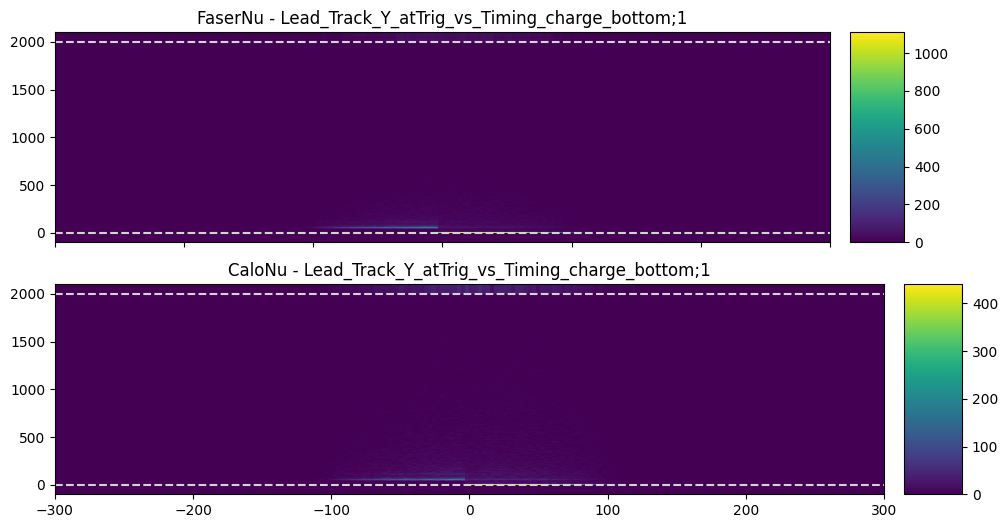

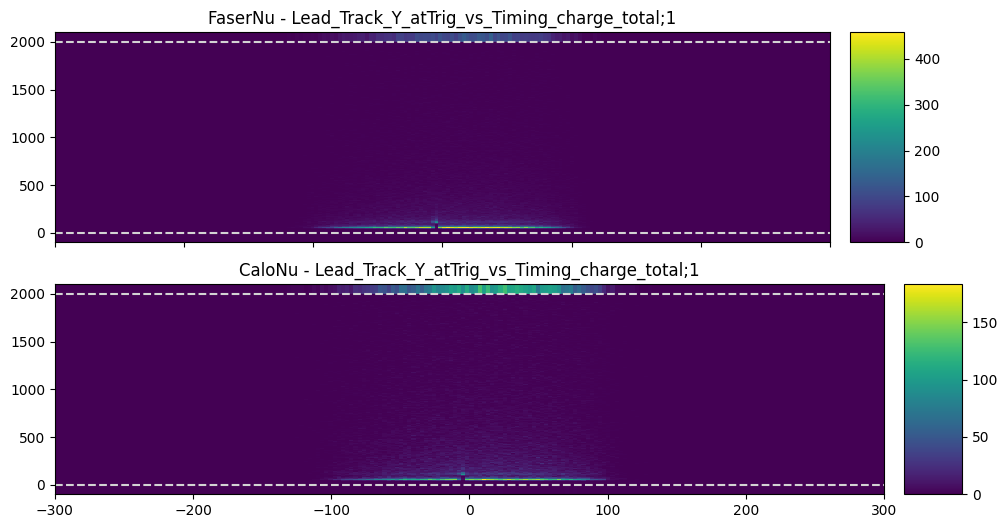

In [5]:
for hist_name, hist_fasernu in hists_fasernu.items():
    fig, ax = plt.subplots(figsize=(10, 6), nrows=2, sharex=True    )
    hist_calonuu = hists_calonuu.get(hist_name)

    density = True

    try:
        mplhep.histplot(hist_fasernu, ax=ax[0], density=density, histtype="step", flow="show", label="FaserNu")
        mplhep.histplot(hist_calonuu, ax=ax[0], density=density, histtype="step", flow="show", label="CaloNu")
        ax[0].legend()
    except Exception as e:
        mplhep.hist2dplot(hist_fasernu, ax=ax[0], label=hist_name, flow="show")
        mplhep.hist2dplot(hist_calonuu, ax=ax[1], label=hist_name, flow="show")
        ax[0].set_title(f"FaserNu - {hist_name}")
        ax[1].set_title(f"CaloNu - {hist_name}")
        continue

    if "truth_dec_x_nu" in hist_name:
        ax[0].axvline(-115, color='r', linestyle='--')
        ax[0].axvline(135, color='r', linestyle='--')
    elif "truth_dec_y_nu" in hist_name:
        ax[0].axvline(-171, color='r', linestyle='--')
        ax[0].axvline(129, color='r', linestyle='--')
    elif "truth_dec_z_nu" in hist_name:
        ax[0].axvline(-3000, color='r', linestyle='--')
        ax[0].axvline(-1950, color='r', linestyle='--')
    
    ratio = (hist_calonuu / hist_calonuu.sum(flow=True)) / (hist_fasernu / hist_fasernu.sum(flow=True))

    # # Set Nans in ratio to 0
    # ratio_ = ratio.to_numpy()[0]
    # ratio_ = np.nan_to_num(ratio_, nan=0.0, posinf=0.0, neginf=0.0)

    for i in range(len(ratio.axes[0].edges) - 1):
        if math.isnan(ratio[i]) or math.isinf(ratio[i]):
            ratio[i] = 0.
        # else:
        #     print(f"ratio[{i}] = {ratio[i]}, {type(ratio[i])}")

    mplhep.histplot(ratio, ax=ax[1], density=True, histtype="step", label="Ratio", flow="show")
    ax[1].set_ylabel("Ratio")
    # print(ratio)
    # ax[1].set_ylim(0, np.amax(ratio.to_numpy()[0]) * 1.2)
    
    ax[0].set_title(hist_name)

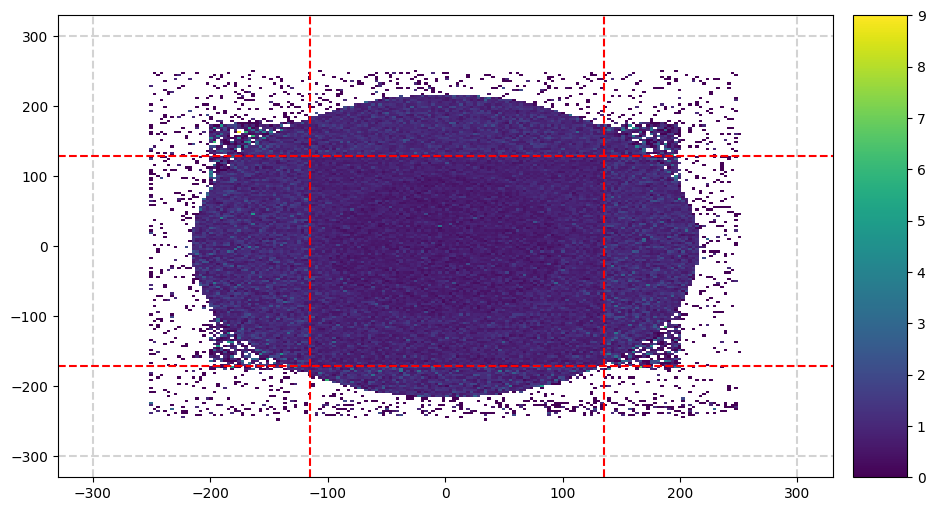

In [6]:
h_fasernu = hists_fasernu.get("truth_dec_x_nu_preFiducialCuts_vs_truth_dec_y_nu_preFiducialCuts;1")
h_calonuu = hists_calonuu.get("truth_dec_x_nu_preFiducialCuts_vs_truth_dec_y_nu_preFiducialCuts;1")
ratio = h_calonuu / h_fasernu

fig, ax = plt.subplots(figsize=(10, 6))
# mplhep.hist2dplot(ratio, ax=ax, label="Ratio", flow="show", norm=LogNorm())
mplhep.hist2dplot(ratio, ax=ax, label="Ratio", flow="show")
ax.axvline(-115, color='r', linestyle='--')
ax.axvline(135, color='r', linestyle='--')
ax.axhline(-171, color='r', linestyle='--')
ax.axhline(129, color='r', linestyle='--')

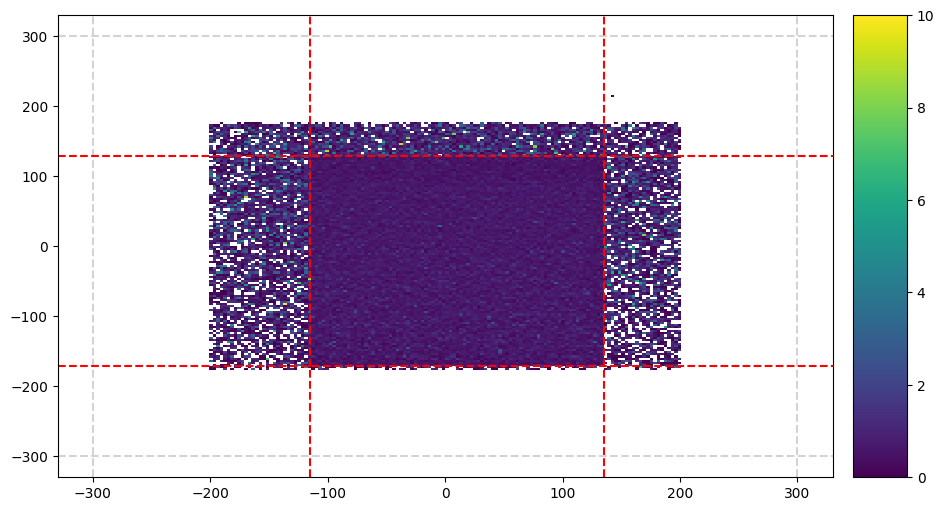

In [7]:
h_fasernu = hists_fasernu.get("truth_dec_x_nu_vs_truth_dec_y_nu;1")
h_calonuu = hists_calonuu.get("truth_dec_x_nu_vs_truth_dec_y_nu;1")
ratio = h_calonuu / h_fasernu

fig, ax = plt.subplots(figsize=(10, 6))
# mplhep.hist2dplot(ratio, ax=ax, label="Ratio", flow="show", norm=LogNorm())
mplhep.hist2dplot(ratio, ax=ax, label="Ratio", flow="show")
ax.axvline(-115, color='r', linestyle='--')
ax.axvline(135, color='r', linestyle='--')
ax.axhline(-171, color='r', linestyle='--')
ax.axhline(129, color='r', linestyle='--')

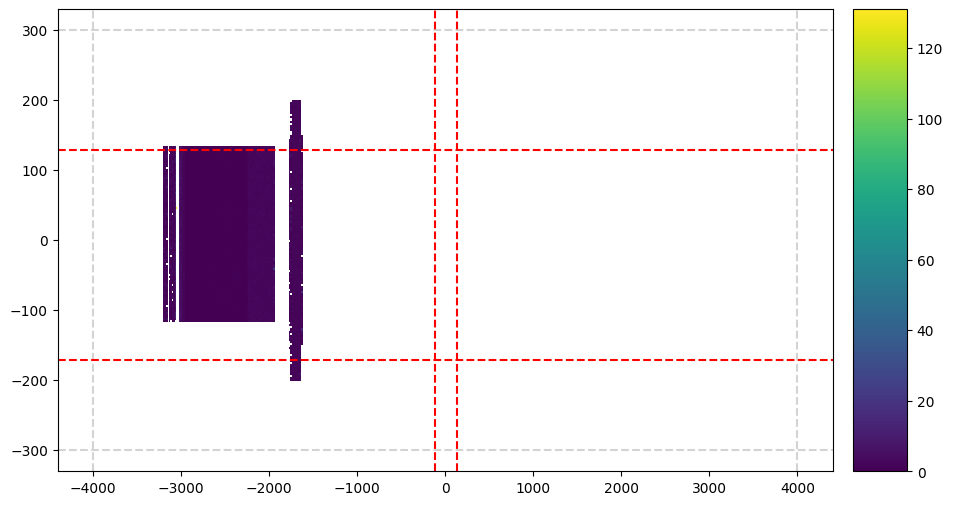

In [8]:
h_fasernu = hists_fasernu.get("truth_dec_z_nu_vs_truth_dec_x_nu;1")
h_calonuu = hists_calonuu.get("truth_dec_z_nu_vs_truth_dec_x_nu;1")
ratio = (h_calonuu / 0.68) / (h_fasernu / 1.1)

fig, ax = plt.subplots(figsize=(10, 6))
# mplhep.hist2dplot(ratio, ax=ax, label="Ratio", flow="show", norm=LogNorm())
mplhep.hist2dplot(ratio, ax=ax, label="Ratio", flow="show")
ax.axvline(-115, color='r', linestyle='--')
ax.axvline(135, color='r', linestyle='--')
ax.axhline(-171, color='r', linestyle='--')
ax.axhline(129, color='r', linestyle='--')

ColormeshArtists(pcolormesh=<matplotlib.collections.QuadMesh object at 0x7f548f801160>, cbar=<matplotlib.colorbar.Colorbar object at 0x7f548fa55ee0>, text=[])

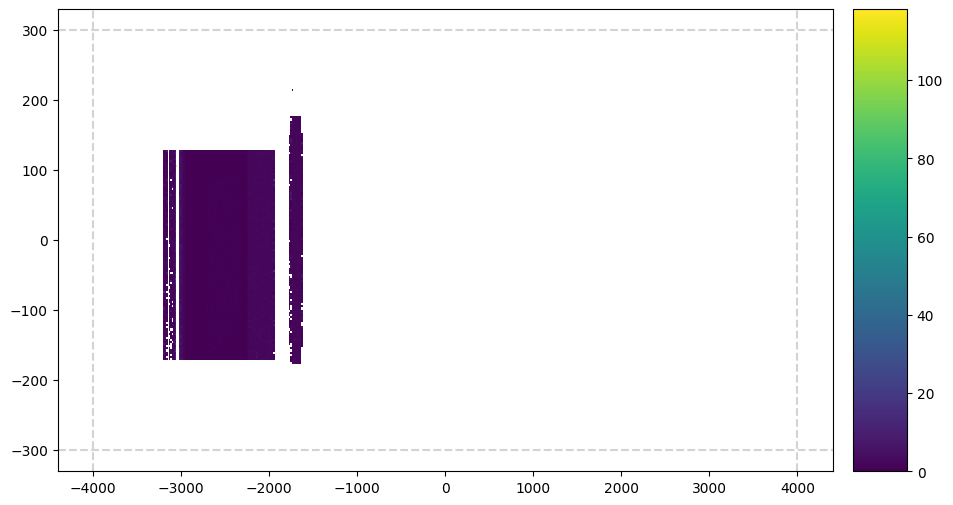

In [9]:
h_fasernu = hists_fasernu.get("truth_dec_z_nu_vs_truth_dec_y_nu;1")
h_calonuu = hists_calonuu.get("truth_dec_z_nu_vs_truth_dec_y_nu;1")
ratio = (h_calonuu / 0.68) / (h_fasernu / 1.1)

fig, ax = plt.subplots(figsize=(10, 6))
# mplhep.hist2dplot(ratio, ax=ax, label="Ratio", flow="show", norm=LogNorm())
mplhep.hist2dplot(ratio, ax=ax, label="Ratio", flow="show")
# ax.axvline(-115, color='r', linestyle='--')
# ax.axvline(135, color='r', linestyle='--')
# ax.axhline(-171, color='r', linestyle='--')
# ax.axhline(129, color='r', linestyle='--')

(-3000.0, -1950.0)

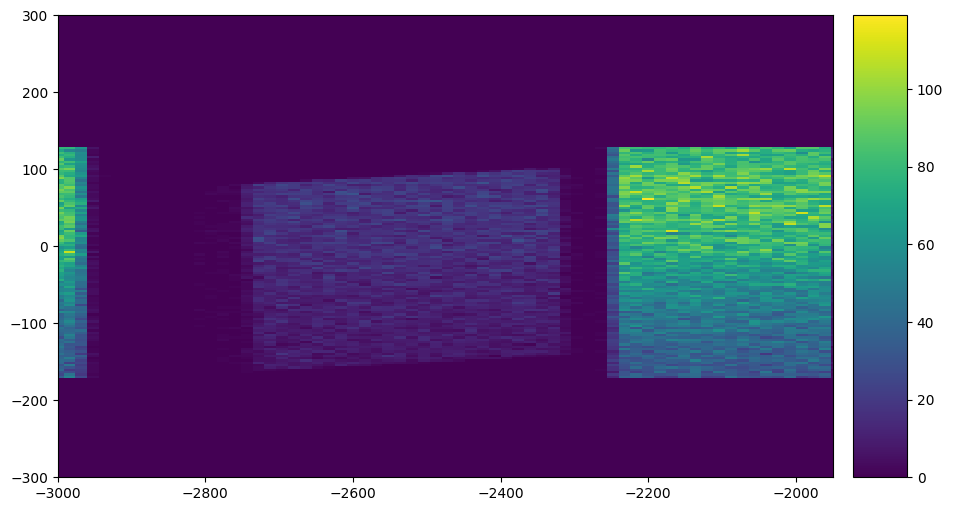

In [10]:
# h_fasernu = hists_fasernu.get("truth_dec_z_nu_vs_truth_dec_y_nu;1")
h_calonuu = hists_calonuu.get("truth_dec_z_nu_vs_truth_dec_y_nu;1")
# ratio = (h_calonuu / 0.68) / (h_fasernu / 1.1)

fig, ax = plt.subplots(figsize=(10, 6))
# mplhep.hist2dplot(ratio, ax=ax, label="Ratio", flow="show", norm=LogNorm())
mplhep.hist2dplot(h_calonuu, ax=ax, flow="show")
# ax.axvline(-115, color='r', linestyle='--')
# ax.axvline(135, color='r', linestyle='--')
# ax.axhline(-171, color='r', linestyle='--')
# ax.axhline(129, color='r', linestyle='--')
ax.set_xlim(-3000, -1950)

(-3000.0, -1950.0)

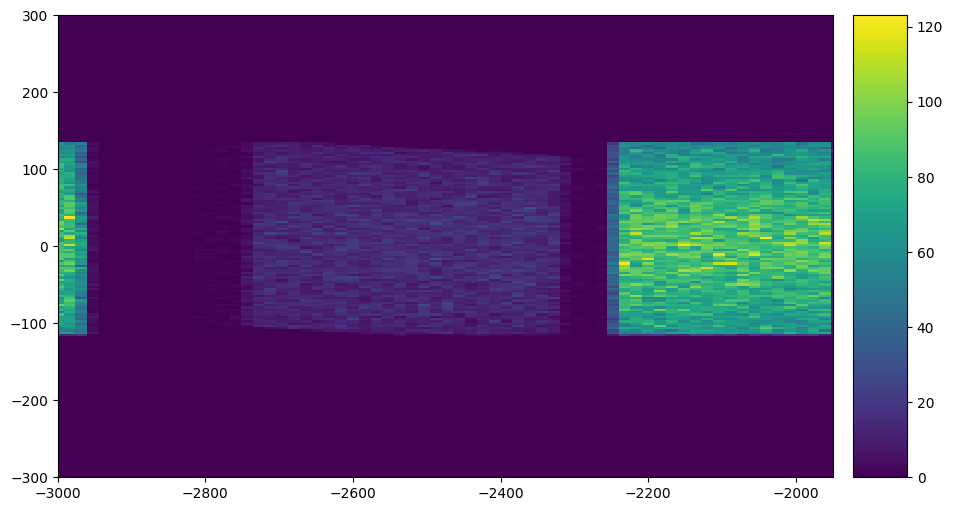

In [11]:
# h_fasernu = hists_fasernu.get("truth_dec_z_nu_vs_truth_dec_y_nu;1")
h_calonuu = hists_calonuu.get("truth_dec_z_nu_vs_truth_dec_x_nu;1")
# ratio = (h_calonuu / 0.68) / (h_fasernu / 1.1)

fig, ax = plt.subplots(figsize=(10, 6))
# mplhep.hist2dplot(ratio, ax=ax, label="Ratio", flow="show", norm=LogNorm())
mplhep.hist2dplot(h_calonuu, ax=ax, flow="show")
# ax.axvline(-115, color='r', linestyle='--')
# ax.axvline(135, color='r', linestyle='--')
# ax.axhline(-171, color='r', linestyle='--')
# ax.axhline(129, color='r', linestyle='--')
ax.set_xlim(-3000, -1950)

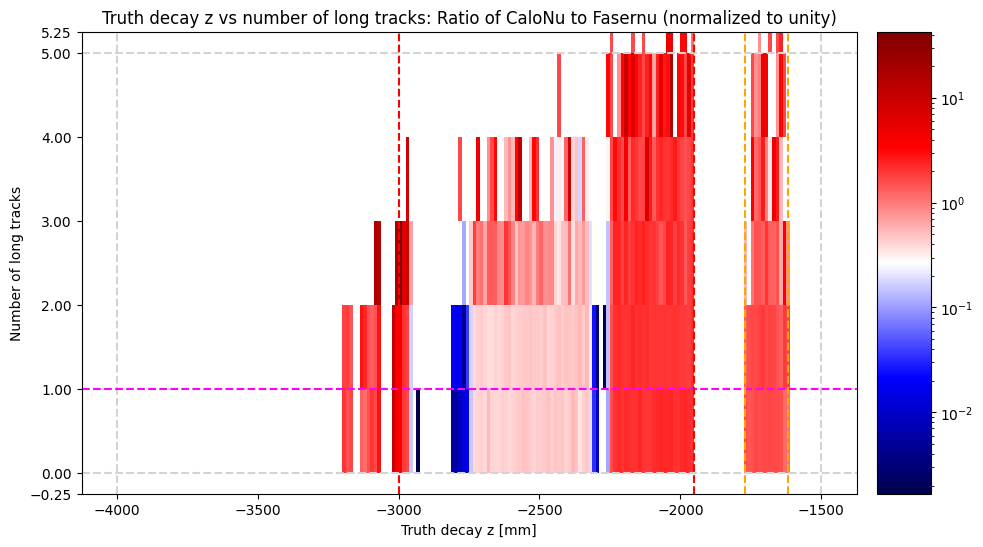

In [12]:
h_fasernu = hists_fasernu.get("truth_dec_z_nu_vs_longTracks;1")
h_calonuu = hists_calonuu.get("truth_dec_z_nu_vs_longTracks;1")
ratio = (h_calonuu / 0.68) / (h_fasernu / 1.1)
# ratio = (h_calonuu / h_calonuu.sum(flow=True)) / (h_fasernu / h_fasernu.sum(flow=True))

fig, ax = plt.subplots(figsize=(10, 6))
# mplhep.hist2dplot(ratio, ax=ax, label="Ratio", flow="show", norm=LogNorm())
mplhep.hist2dplot(ratio, ax=ax, label="Ratio", flow="show", norm=LogNorm(), cmap="seismic")
# ax.axvline(-115, color='r', linestyle='--')
# ax.axvline(135, color='r', linestyle='--')
# ax.axhline(-171, color='r', linestyle='--')
# ax.axhline(129, color='r', linestyle='--')
ax.set_xlabel("Truth decay z [mm]")
ax.set_ylabel("Number of long tracks")
ax.set_title("Truth decay z vs number of long tracks: Ratio of CaloNu to Fasernu (normalized to unity)")
ax.axhline(1, color='magenta', linestyle='--')
ax.axvline(-3000, color='r', linestyle='--')
ax.axvline(-1950, color='r', linestyle='--')
ax.axvline(-1769.65, color='orange', linestyle='--')
ax.axvline(-1619.65, color='orange', linestyle='--')

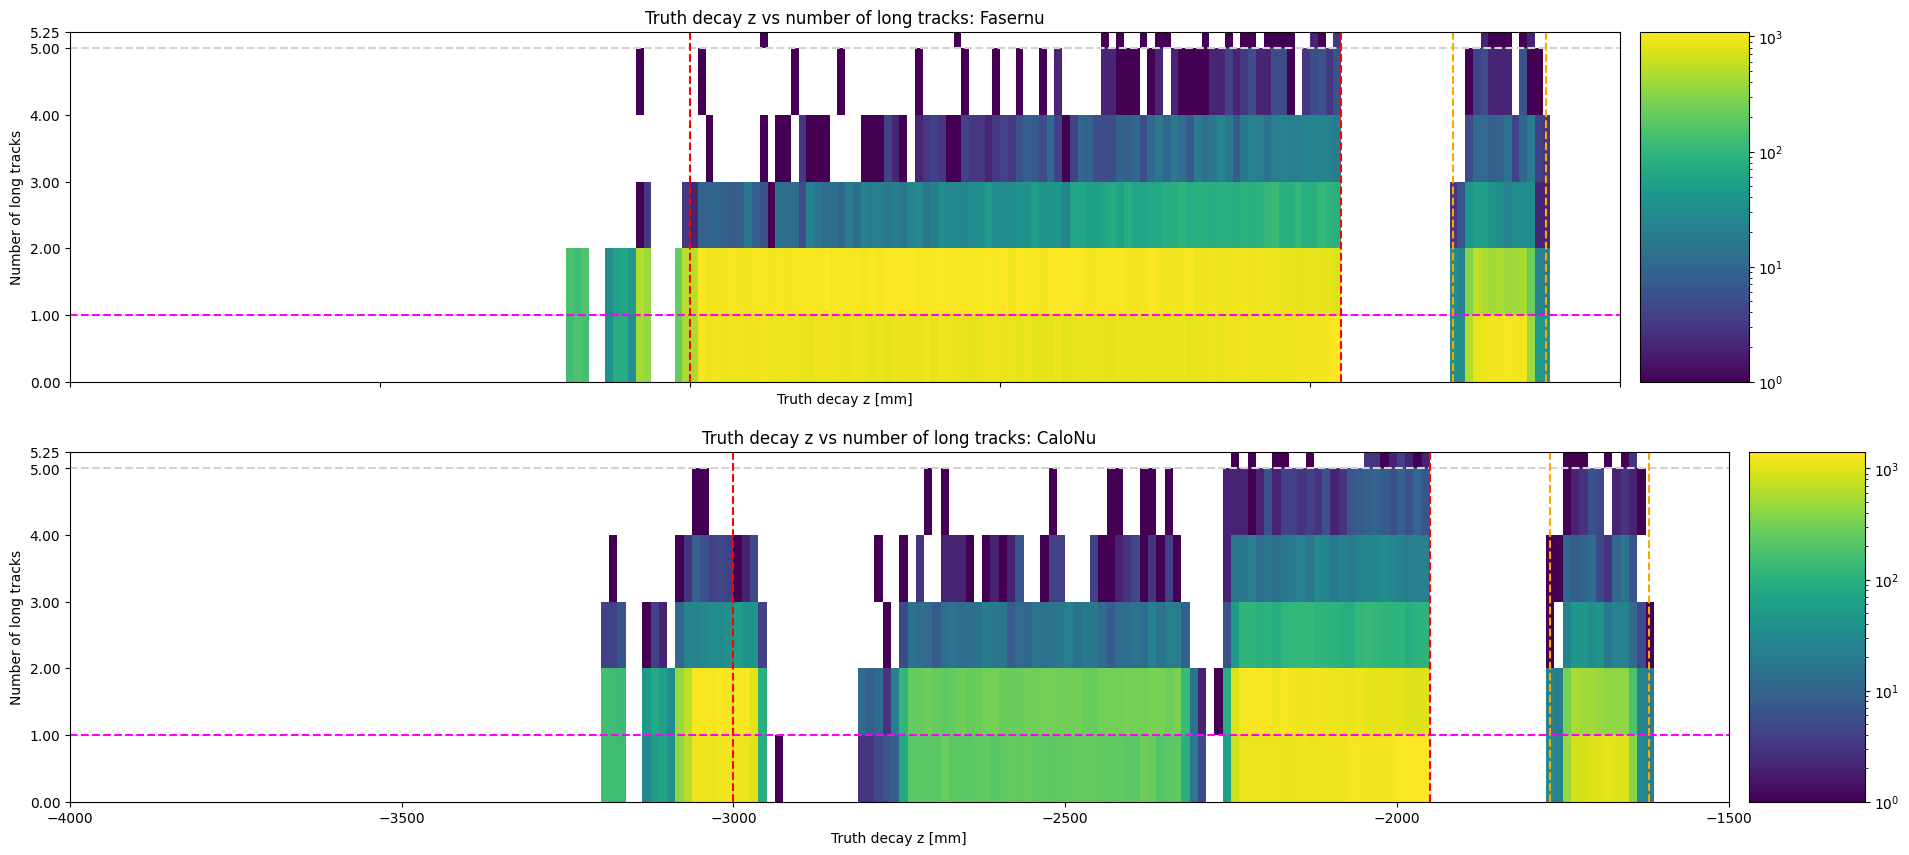

In [13]:
h_fasernu = hists_fasernu.get("truth_dec_z_nu_vs_longTracks;1")
h_calonuu = hists_calonuu.get("truth_dec_z_nu_vs_longTracks;1")

fig, ax = plt.subplots(figsize=(20, 10), nrows=2, ncols=1, sharex=True)
# mplhep.hist2dplot(ratio, ax=ax, label="Ratio", flow="show", norm=LogNorm())
mplhep.hist2dplot(h_fasernu, ax=ax[0], label="Fasernu", flow="show", norm=LogNorm(), cmap="viridis")
mplhep.hist2dplot(h_calonuu, ax=ax[1], label="CaloNu", flow="show", norm=LogNorm(), cmap="viridis")
# ax.axvline(-115, color='r', linestyle='--')
# ax.axvline(135, color='r', linestyle='--')
# ax.axhline(-171, color='r', linestyle='--')
# ax.axhline(129, color='r', linestyle='--')
ax[0].set_xlabel("Truth decay z [mm]")
ax[0].set_ylabel("Number of long tracks")
ax[0].set_title("Truth decay z vs number of long tracks: Fasernu")
ax[1].set_xlabel("Truth decay z [mm]")
ax[1].set_ylabel("Number of long tracks")
ax[1].set_title("Truth decay z vs number of long tracks: CaloNu")
ax[0].axhline(1, color='magenta', linestyle='--')
ax[1].axhline(1, color='magenta', linestyle='--')
ax[0].axvline(-3000, color='r', linestyle='--')
ax[0].axvline(-1950, color='r', linestyle='--')
ax[0].axvline(-1769.65, color='orange', linestyle='--')
ax[0].axvline(-1619.65, color='orange', linestyle='--')
ax[1].axvline(-3000, color='r', linestyle='--')
ax[1].axvline(-1950, color='r', linestyle='--')
ax[1].axvline(-1769.65, color='orange', linestyle='--')
ax[1].axvline(-1619.65, color='orange', linestyle='--')

/tmp/ipykernel_2994580/455631230.py:6: RuntimeWarning: invalid value encountered in divide
  ratio_fasernu = n1 / n0


Text(0, 0.5, 'Ratio of events with long tracks to events without long tracks')

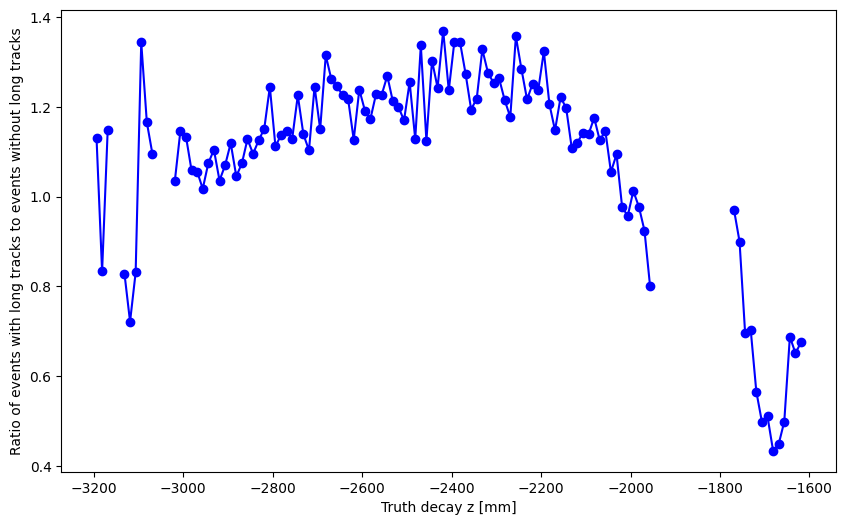

In [14]:
h_fasernu = hists_fasernu.get("truth_dec_z_nu_vs_longTracks;1")

n0 = h_fasernu.values()[:,0]
n1 = h_fasernu.values()[:,1:-1].sum(axis=1)

ratio_fasernu = n1 / n0
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(h_fasernu.axes[0].centers, ratio_fasernu, marker='o', linestyle='-', color='b')
ax.set_xlabel("Truth decay z [mm]")
ax.set_ylabel("Ratio of events with long tracks to events without long tracks")

/tmp/ipykernel_2994580/2179677117.py:9: RuntimeWarning: divide by zero encountered in divide
  ratio_calonu = n1 / n0
/tmp/ipykernel_2994580/2179677117.py:9: RuntimeWarning: invalid value encountered in divide
  ratio_calonu = n1 / n0


Text(0, 0.5, 'Ratio of events with long tracks to events without long tracks')

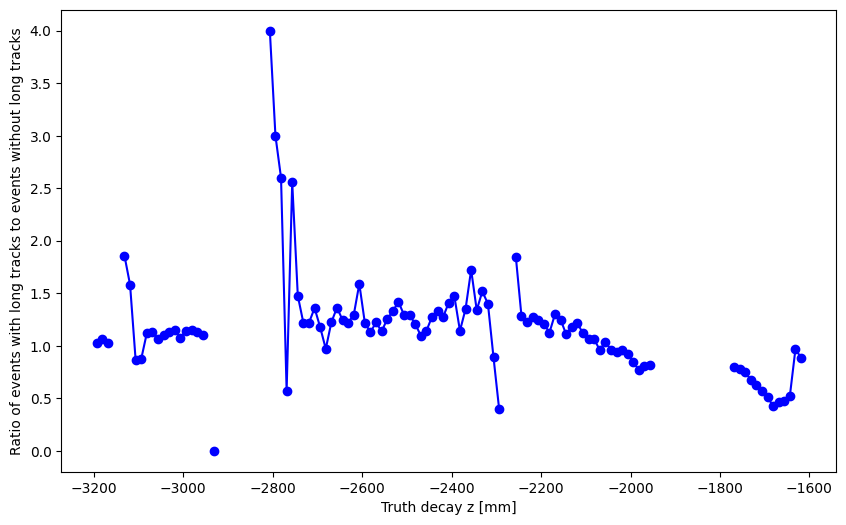

In [15]:
h_calonuu = hists_calonuu.get("truth_dec_z_nu_vs_longTracks;1")

n0 = h_calonuu.values()[:,0]
n1 = h_calonuu.values()[:,1:-1].sum(axis=1)

# print(h_calonuu.values()[:,1:-1][100])
# print(n1[100])

ratio_calonu = n1 / n0
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(h_calonuu.axes[0].centers, ratio_calonu, marker='o', linestyle='-', color='b')
ax.set_xlabel("Truth decay z [mm]")
ax.set_ylabel("Ratio of events with long tracks to events without long tracks")

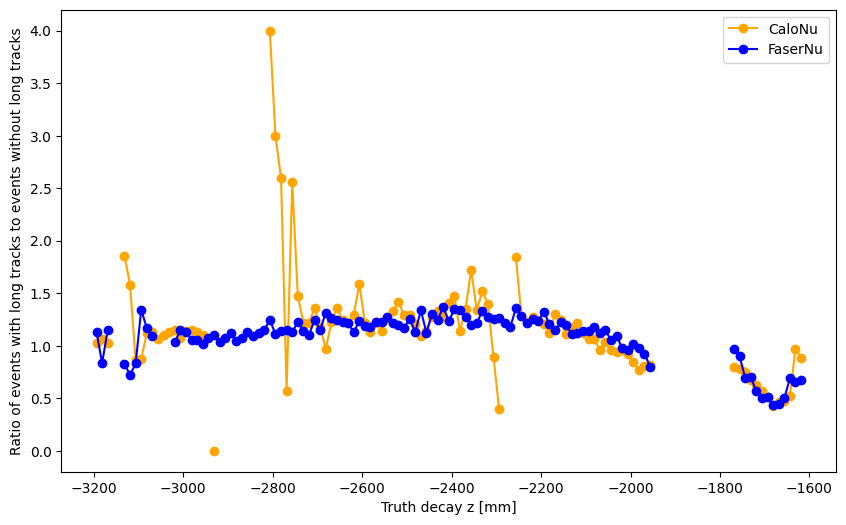

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(h_calonuu.axes[0].centers, ratio_calonu, marker='o', linestyle='-', color='orange', label="CaloNu")
ax.plot(h_calonuu.axes[0].centers, ratio_fasernu, marker='o', linestyle='-', color='b', label="FaserNu")
ax.set_xlabel("Truth decay z [mm]")
ax.set_ylabel("Ratio of events with long tracks to events without long tracks")
ax.legend()